In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [28]:
import matplotlib.pyplot as plt

In [29]:
titanic_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

In [30]:
titanic_df.shape

(891, 12)

In [31]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [32]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [33]:
titanic_df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [34]:
titanic_df["Pclass"].unique()

array([3, 1, 2])

In [35]:
titanic_df["Parch"]

0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    2
889    0
890    0
Name: Parch, Length: 891, dtype: int64

In [36]:
titanic_df["SibSp"]

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: SibSp, Length: 891, dtype: int64

In [37]:
train_data = titanic_df.set_index("PassengerId")
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv", index_col="PassengerId")

In [38]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
test_data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [40]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [41]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [42]:
cat_attribs = ["Pclass", "Sex", "Embarked"]
num_attribs = ["Age", "SibSp", "Fare", "Parch"]

In [43]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("Encoder", OneHotEncoder(sparse_output=False))
])

In [44]:
num_pipeline = Pipeline([
    ("Imputer", SimpleImputer(strategy="median")),
    ("Scaler", StandardScaler())
])

In [45]:
preprocess_pipeline = ColumnTransformer([
    ("Num", num_pipeline, num_attribs),
    ("Cat", cat_pipeline, cat_attribs)
])

In [46]:
X_train = preprocess_pipeline.fit_transform(train_data[num_attribs + cat_attribs])

In [47]:
X_train

array([[-0.56573646,  0.43279337, -0.50244517, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.66386103,  0.43279337,  0.78684529, ...,  1.        ,
         0.        ,  0.        ],
       [-0.25833709, -0.4745452 , -0.48885426, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.1046374 ,  0.43279337, -0.17626324, ...,  0.        ,
         0.        ,  1.        ],
       [-0.25833709, -0.4745452 , -0.04438104, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.20276197, -0.4745452 , -0.49237783, ...,  0.        ,
         1.        ,  0.        ]])

In [48]:
y_train = train_data["Survived"]

In [49]:
from sklearn.ensemble import RandomForestClassifier

randomforest_clf = RandomForestClassifier(random_state=42)
randomforest_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
y_pred = randomforest_clf.predict(X_train)

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [52]:
accuracy_score(y_train, y_pred)

0.9797979797979798

In [53]:
precision_score(y_train, y_pred)

0.990909090909091

In [54]:
recall_score(y_train, y_pred)

0.956140350877193

In [55]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(randomforest_clf, X_train, y_train, cv=10, verbose=2)
rf_cv.mean()

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    1.5s finished


np.float64(0.8103870162297129)

In [56]:
from sklearn.neighbors import KNeighborsClassifier

kn_clf = KNeighborsClassifier()
kn_cv = cross_val_score(kn_clf, X_train, y_train, cv=10, verbose=2)
kn_cv.mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished


np.float64(0.8069912609238452)

In [57]:
from sklearn.svm import SVC

svc = SVC(gamma="auto")
svc_cv = cross_val_score(svc, X_train, y_train, cv=10, verbose=2)
svc_cv.mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.2s finished


np.float64(0.8249313358302123)

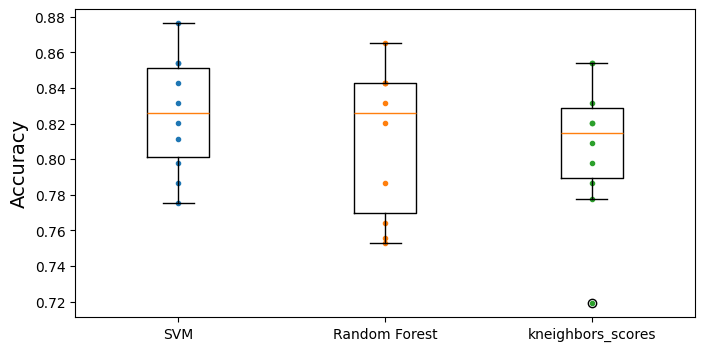

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot([1]*10, svc_cv, ".")
plt.plot([2]*10, rf_cv, ".")
plt.plot([3]*10, kn_cv, ".")
plt.boxplot([svc_cv, rf_cv, kn_cv], tick_labels=("SVM","Random Forest", "kneighbors_scores"))
plt.ylabel("Accuracy", fontsize=14)
plt.show()

In [59]:
train_data["Name"].isin(["Mr", "Mrs", "Miss"])

PassengerId
1      False
2      False
3      False
4      False
5      False
       ...  
887    False
888    False
889    False
890    False
891    False
Name: Name, Length: 891, dtype: bool

In [60]:
def extract_title(data):
    title_extracted = []
    titles = ["Mr.","Miss.", "Master.", "Mrs."]
    
    for i in range(len(data)):
        found = None
        for j in range(len(titles)):
            if titles[j] in data[i]:
                found = titles[j]
                break
        title_extracted.append(found)
        
    return title_extracted

In [61]:
data = list(train_data["Name"])
train_data["Title"] = extract_title(data)

In [62]:
train_data[train_data["Title"].isna()]["Sex"]

PassengerId
31       male
150      male
151      male
246      male
250      male
318      male
370    female
399      male
444    female
450      male
537      male
557    female
600      male
627      male
633      male
642    female
648      male
661      male
695      male
711    female
746      male
760    female
767      male
797    female
823      male
849      male
887      male
Name: Sex, dtype: object

In [63]:
train_data["Title"].isna().sum()

np.int64(27)

In [64]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.


In [65]:
import re

def extract_ticket_no(data):
    ticket_no = []
    for i in range(len(data)):
        match = re.search(r"(\w+)$", data[i])
        ticket_no.append(match.group())
    return ticket_no

In [66]:
train_data["Ticket_No"] = extract_ticket_no(list(train_data["Ticket"]))

In [67]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_No
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.,21171
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.,17599
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.,3101282
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.,113803
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.,373450


In [68]:
train_data["FamilySize"] = train_data["Parch"] + train_data["SibSp"]

In [69]:
train_data.loc[train_data["Title"].isna() & (train_data["Sex"] == "male"), "Title"] = "Mr."
train_data.loc[train_data["Title"].isna() & (train_data["Sex"] == "female"), "Title"] = "Miss."

In [70]:
title_group = train_data[["Title", "Survived"]].groupby(["Title"])
title_group["Survived"].mean()

Title
Master.    0.575000
Miss.      0.708995
Mr.        0.160149
Mrs.       0.792000
Name: Survived, dtype: float64

In [71]:
title_group.size()

Title
Master.     40
Miss.      189
Mr.        537
Mrs.       125
dtype: int64

In [72]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_No,FamilySize
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.,21171,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.,17599,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.,3101282,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.,113803,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.,373450,0


In [73]:
train_data["AgeBracket"] = pd.qcut(train_data["Age"], 5)

In [74]:
train_data.drop("AgeBracket", axis=1, inplace=True)

In [75]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Ticket_No,FamilySize
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr.,21171,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs.,17599,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss.,3101282,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs.,113803,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr.,373450,0


In [76]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [77]:
train_data = train_data.drop(["Ticket", "Cabin", "Title", "Ticket_No", "FamilySize"], axis=1)
test_data = test_data.drop(["Ticket", "Cabin"], axis=1)

In [78]:
combine = [train_data, test_data]

In [79]:
for dataset in combine:
    dataset["Title"] = dataset["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [80]:
pd.crosstab(train_data["Title"], train_data["Sex"])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [81]:
for dataset in combine:
    dataset["Title"] = dataset["Title"].replace(["Sir", "Rev", "Dona", "Dr", "Major", "Lady", "Capt", "Col", "Don", "Countess", "Jonkheer"], "Rare")
    dataset["Title"] = dataset["Title"].replace("Mlle", "Miss")
    dataset["Title"] = dataset["Title"].replace("Ms", "Miss")
    dataset["Title"] = dataset["Title"].replace("Mme", "Mrs")

In [82]:
train_data[["Title", "Survived"]].groupby(["Title"], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


In [83]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset["Title"] = dataset["Title"].map(title_mapping)
    dataset["Title"] = dataset["Title"].fillna(0)

In [84]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,3
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,3
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1


In [85]:
train_data = train_data.drop(["Name"], axis=1)
test_data = test_data.drop(["Name"], axis=1)
combine = [train_data, test_data]

In [86]:
for dataset in combine:
    dataset["Sex"] = dataset["Sex"].map({"male": 0, "female": 1}).astype(int)

train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
PassengerId,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,S,1
2,1,1,1,38.0,1,0,71.2833,C,3
3,1,3,1,26.0,0,0,7.9250,S,2
4,1,1,1,35.0,1,0,53.1000,S,3
5,0,3,0,35.0,0,0,8.0500,S,1


In [87]:
for dataset in combine:
    dataset["FamilySize"] = dataset["Parch"] + dataset["SibSp"]

train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
PassengerId,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,S,1,1
2,1,1,1,38.0,1,0,71.2833,C,3,1
3,1,3,1,26.0,0,0,7.9250,S,2,0
4,1,1,1,35.0,1,0,53.1000,S,3,1
5,0,3,0,35.0,0,0,8.0500,S,1,0


In [88]:
train_data = train_data.drop(["SibSp", "Parch"], axis=1)
test_data = test_data.drop(["SibSp", "Parch"], axis=1)


In [89]:
train_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
PassengerId,,,,,,,,
1,0,3,0,22.0,7.2500,S,1,1
2,1,1,1,38.0,71.2833,C,3,1
3,1,3,1,26.0,7.9250,S,2,0
4,1,1,1,35.0,53.1000,S,3,1
5,0,3,0,35.0,8.0500,S,1,0


In [90]:
train_data["AgeBucket"] = pd.cut(train_data["Age"], 5)
train_data[["AgeBucket", "Survived"]].groupby(["AgeBucket"], as_index=False, observed=True).mean().sort_values(by="AgeBucket", ascending=True)

,AgeBucket,Survived
0,"(0.34, 16.336]",0.550000
1,"(16.336, 32.252]",0.369942
2,"(32.252, 48.168]",0.404255
3,"(48.168, 64.084]",0.434783
4,"(64.084, 80.0]",0.090909


In [91]:
combine = [train_data, test_data]

for dataset in combine:    
    dataset.loc[ dataset["Age"] <= 16, "Age"] = 0
    dataset.loc[(dataset["Age"] > 16) & (dataset["Age"] <= 32), "Age"] = 1
    dataset.loc[(dataset["Age"] > 32) & (dataset["Age"] <= 48), "Age"] = 2
    dataset.loc[(dataset["Age"] > 48) & (dataset["Age"] <= 64), "Age"] = 3
    dataset.loc[ dataset["Age"] > 64, "Age"]
    
train_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,AgeBucket
PassengerId,,,,,,,,,
1,0,3,0,1.0,7.2500,S,1,1,"(16.336, 32.252]"
2,1,1,1,2.0,71.2833,C,3,1,"(32.252, 48.168]"
3,1,3,1,1.0,7.9250,S,2,0,"(16.336, 32.252]"
4,1,1,1,2.0,53.1000,S,3,1,"(32.252, 48.168]"
5,0,3,0,2.0,8.0500,S,1,0,"(32.252, 48.168]"


In [92]:
train_data = train_data.drop(["AgeBucket"], axis=1)
combine = [train_data, test_data]

In [93]:
train_data[["FamilySize", "Survived"]].groupby(["FamilySize"], as_index=True, observed=True).mean()

,Survived
FamilySize,
0,0.303538
1,0.552795
2,0.578431
3,0.724138
4,0.200000
5,0.136364
6,0.333333
7,0.000000
10,0.000000


In [94]:
train_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
PassengerId,,,,,,,,
1,0,3,0,1.0,7.2500,S,1,1
2,1,1,1,2.0,71.2833,C,3,1
3,1,3,1,1.0,7.9250,S,2,0
4,1,1,1,2.0,53.1000,S,3,1
5,0,3,0,2.0,8.0500,S,1,0


In [95]:
cat_attribs = ["Embarked"]
num_attribs = ["Fare"]

cat_pipeline = Pipeline([
    ("Imputer", SimpleImputer(strategy="most_frequent")),
    ("Encoder", OneHotEncoder(sparse_output=False)),
])

num_pipeline = Pipeline([
    ("Imputer", SimpleImputer(strategy="median")),
    ("Scaler", StandardScaler())
])

In [96]:
X_train, y = train_data.drop(["Survived"], axis=1), train_data["Survived"]

In [97]:
X_train.head()

,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
PassengerId,,,,,,,
1,3,0,1.0,7.2500,S,1,1
2,1,1,2.0,71.2833,C,3,1
3,3,1,1.0,7.9250,S,2,0
4,1,1,2.0,53.1000,S,3,1
5,3,0,2.0,8.0500,S,1,0


In [98]:
preprocessor = ColumnTransformer([
    ("Imputer", SimpleImputer(strategy="most_frequent"), ["Age"]),
    ("Num", num_pipeline, num_attribs),
    ("Cat", cat_pipeline, cat_attribs),
], remainder="passthrough")

X_final = preprocessor.fit_transform(X_train)

In [99]:
X_final

array([[ 1.        , -0.50244517,  0.        , ...,  0.        ,
         1.        ,  1.        ],
       [ 2.        ,  0.78684529,  1.        , ...,  1.        ,
         3.        ,  1.        ],
       [ 1.        , -0.48885426,  0.        , ...,  1.        ,
         2.        ,  0.        ],
       ...,
       [ 1.        , -0.17626324,  0.        , ...,  1.        ,
         2.        ,  3.        ],
       [ 1.        , -0.04438104,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [ 1.        , -0.49237783,  0.        , ...,  0.        ,
         1.        ,  0.        ]])

In [100]:
X_final.shape

(891, 9)

In [101]:
random_forest_clf = RandomForestClassifier(random_state=42)
random_forest_clf.fit(X_final, y)
y_pred = random_forest_clf.predict(X_final)
accuracy_score(y, y_pred)

0.9450056116722784

In [102]:
random_forest_score = cross_val_score(random_forest_clf, X_final, y, cv=10, verbose=2)
random_forest_score.mean()

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    1.4s finished


np.float64(0.8159925093632958)

In [103]:
kneighbors_clf = KNeighborsClassifier()
kneighbors_clf_score = cross_val_score(kneighbors_clf, X_final, y, cv=10, verbose=2)
kneighbors_clf_score.mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished


np.float64(0.8182521847690387)

In [104]:
svm_clf = SVC(gamma="auto")
svm_clf_score = cross_val_score(svm_clf, X_final, y, cv=10, verbose=2)
svm_clf_score.mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.1s finished


np.float64(0.8316604244694131)

In [105]:
from xgboost import XGBClassifier

xg_boost_clf = XGBClassifier()
xg_boost_score = cross_val_score(xg_boost_clf, X_final, y, cv=10, verbose=2)
xg_boost_score.mean()

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.5s finished


np.float64(0.8306117353308364)

In [106]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_clf = DecisionTreeClassifier()
decision_score = cross_val_score(decision_tree_clf, X_final, y, cv=10, verbose=2)
decision_score.mean()

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.0s finished


np.float64(0.8080898876404493)

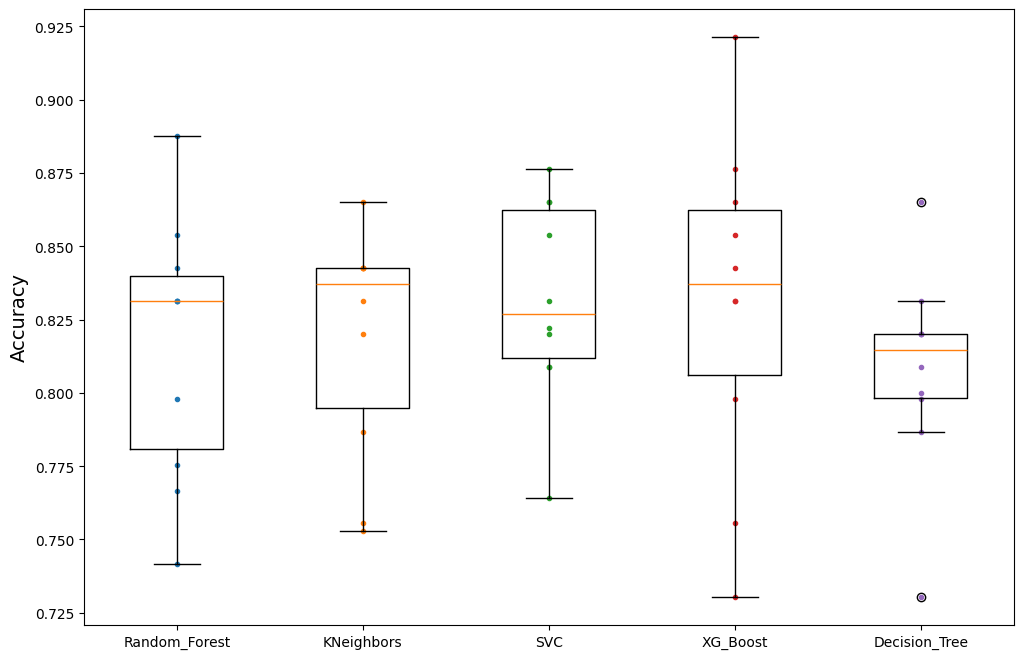

In [107]:
plt.figure(figsize=(12, 8))
plt.plot([1]*10, random_forest_score, ".")
plt.plot([2]*10, kneighbors_clf_score, ".")
plt.plot([3]*10, svm_clf_score, ".")
plt.plot([4]*10, xg_boost_score, ".")
plt.plot([5]*10, decision_score, ".")
plt.boxplot([random_forest_score, kneighbors_clf_score, svm_clf_score, xg_boost_score, decision_score],
           tick_labels=("Random_Forest", "KNeighbors", "SVC", "XG_Boost", "Decision_Tree"))
plt.ylabel("Accuracy", fontsize=14)
plt.show()

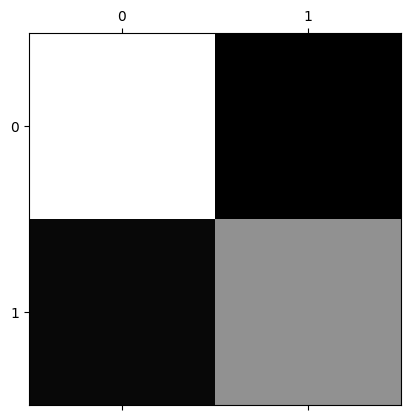

In [108]:
from sklearn.metrics import confusion_matrix

conf_mx = confusion_matrix(y, y_pred)
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

In [109]:
from sklearn.model_selection import GridSearchCV
param_grid = [
   {
       "n_estimators": [100, 300, 500],
       "learning_rate": [0.1, 0.2],
       "max_depth": [3, 4],
       "subsample": [0.5, 0.8, 1.0],
   }
]
xg_boost = XGBClassifier( objective="binary:logistic", eval_metric="logloss")
grid_search_xg = GridSearchCV(xg_boost, param_grid, cv=5, return_train_score=True, verbose=2, n_jobs=-1)
grid_search_xg.fit(X_final, y)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid=[{'learning_rate': [0.1, 0.2], 'max_depth': [3, 4],
                          'n_estimators': [100, 300, 500],
                          'subsample': [0.5, 0.8, 1.0]}],
             return_train_score=True, verbose=2)

In [110]:
grid_search_xg.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.5}

In [111]:
print(grid_search_xg.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.5}


In [112]:
xg_model = grid_search_xg.best_estimator_

In [113]:
xg_model_score = cross_val_score(xg_model, X_final, y, cv=10, verbose=2)
xg_model_score.mean()

[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.9s finished


np.float64(0.8406741573033708)

In [114]:
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 5, 10, 20],
    "max_features": ["sqrt","log2", None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_clf = RandomForestClassifier(random_state=42)
rf_grid_search = GridSearchCV(rf_clf, param_grid=param_grid, cv=5, return_train_score=True, verbose=2, n_jobs=-1)
rf_grid_search.fit(X_final, y)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=300, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=300, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] EN

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [200, 300, 400]},
             return_train_score=True, verbose=2)

In [115]:
rf_model = rf_grid_search.best_estimator_

In [116]:
rf_model_score = cross_val_score(rf_model, X_final, y, cv=10, verbose=2)
rf_model_score.mean()

[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s
[CV] END .................................................... total time=   0.3s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    3.4s finished


np.float64(0.8339450686641697)

In [117]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[("RandomForest", rf_model), ("XGB", xg_model)],
    final_estimator=LogisticRegression()
)

stack.fit(X_final, y)

StackingClassifier(estimators=[('RandomForest',
                                RandomForestClassifier(max_depth=10,
                                                       max_features=None,
                                                       min_samples_split=5,
                                                       n_estimators=200,
                                                       random_state=42)),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=Fals...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=3,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=300, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())

In [118]:
Stack_score = cross_val_score(stack, X_final, y, cv=10, verbose=2)

[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.4s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.3s
[CV] END .................................................... total time=   2.4s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:   23.5s finished


In [119]:
Stack_score.mean()

np.float64(0.842896379525593)

In [120]:
cvresult_xg = grid_search_xg.cv_results_
cvresult_df = pd.DataFrame(cvresult_xg)

cvresult_rf = rf_grid_search.cv_results_
cvresult_df2 = pd.DataFrame(cvresult_rf)

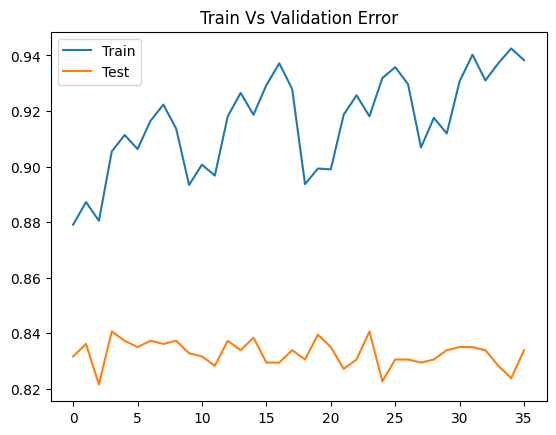

In [121]:
plt.plot(cvresult_df["mean_train_score"], label="Train")
plt.plot(cvresult_df["mean_test_score"], label="Test")
plt.legend()
plt.title("Train Vs Validation Error")
plt.show()

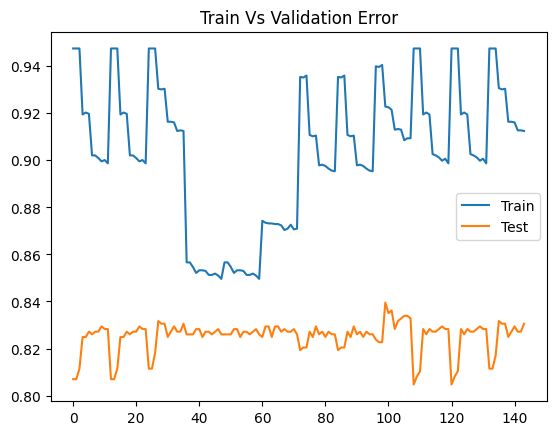

In [122]:
plt.plot(cvresult_df2["mean_train_score"], label="Train")
plt.plot(cvresult_df2["mean_test_score"], label="Test")
plt.legend()
plt.title("Train Vs Validation Error")
plt.show()

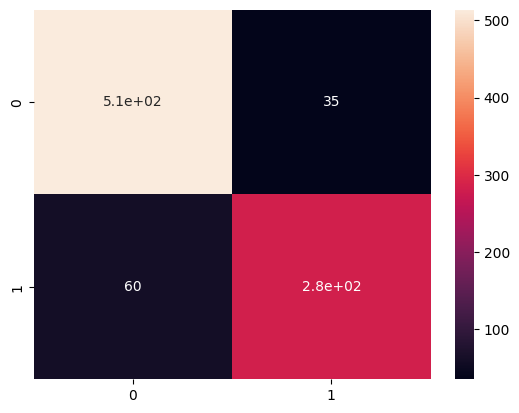

In [123]:
import seaborn as sns

y_xg_pred = xg_model.predict(X_final)
y_rf_pred = rf_model.predict(X_final)

cm_for_xg = confusion_matrix(y, y_xg_pred)
sns.heatmap(cm_for_xg, annot=True)
plt.show()

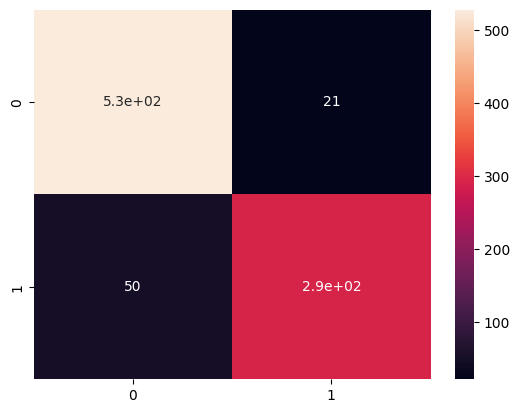

In [124]:
cm_for_rf = confusion_matrix(y, y_rf_pred)
sns.heatmap(cm_for_rf, annot=True)
plt.show()

In [125]:
y_final = np.array(y)

In [126]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict

y_scores = xg_model.predict_proba(X_final)[:,1]

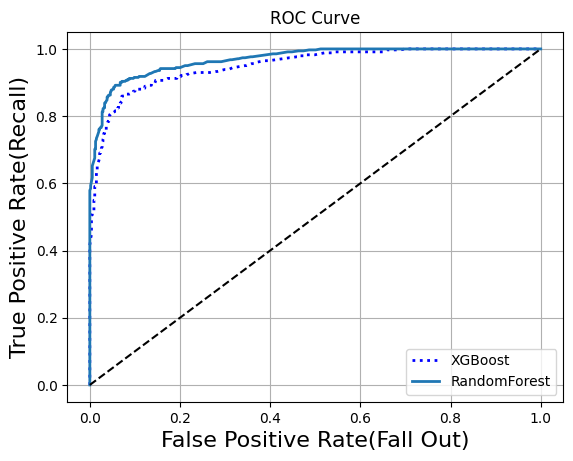

In [127]:
y_scores_rf = rf_model.predict_proba(X_final)[:,1]

fpr, tpr, _ = roc_curve(y_final, y_scores)
fpr_forest, tpr_forest, _ = roc_curve(y_final, y_scores_rf)

plt.plot(fpr, tpr, "b:", linewidth=2, label="XGBoost")
plt.plot(fpr_forest, tpr_forest, linewidth=2, label="RandomForest")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate(Fall Out)", fontsize=16)
plt.ylabel("True Positive Rate(Recall)", fontsize=16)
plt.grid(True)
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

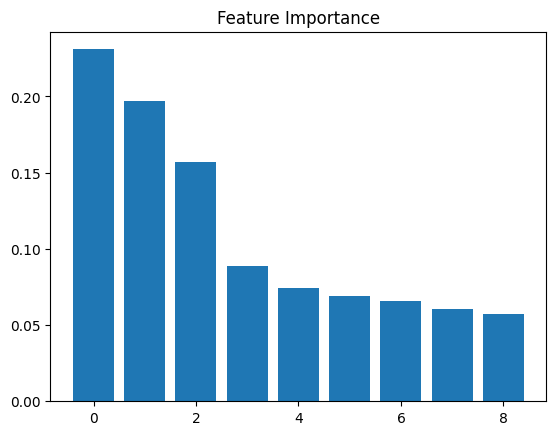

In [128]:
importances = xg_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.show()

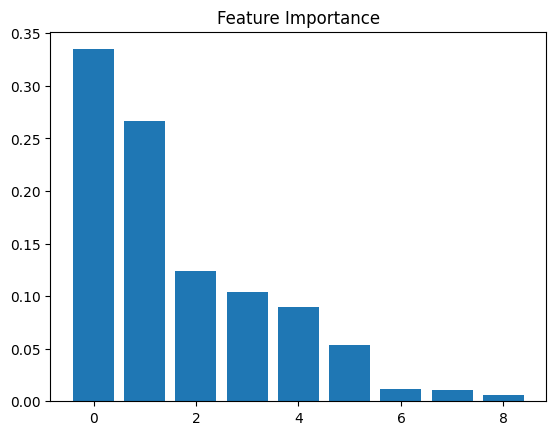

In [129]:
importances2 = rf_model.feature_importances_
indices2 = np.argsort(importances2)[::-1]

plt.figure()
plt.title("Feature Importance")
plt.bar(range(len(importances2)), importances2[indices2])
plt.show()

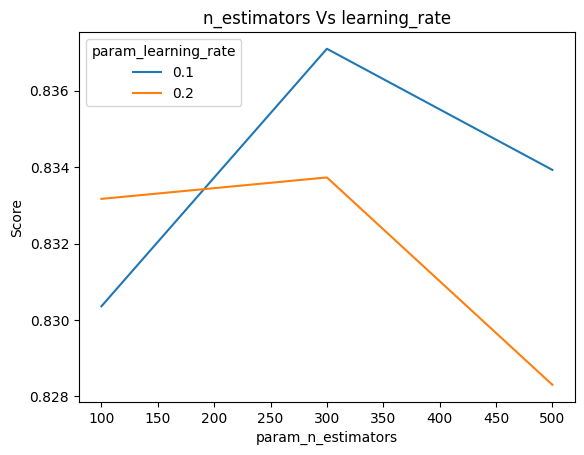

In [130]:
pivot1 = cvresult_df.pivot_table(
    values="mean_test_score",
    index="param_n_estimators",
    columns="param_learning_rate"
)

pivot1.plot()
plt.ylabel("Score")
plt.title("n_estimators Vs learning_rate")
plt.show()

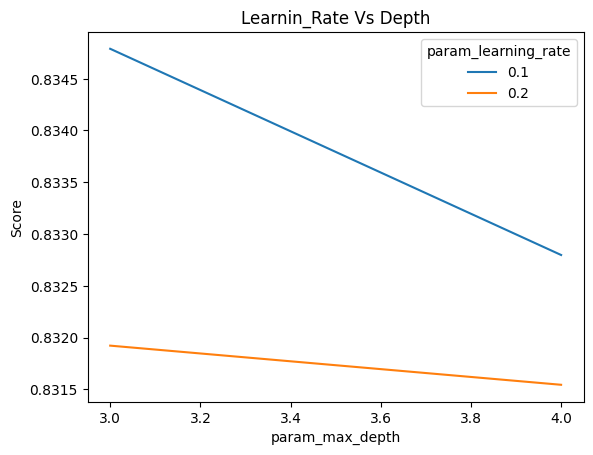

In [131]:
pivot2 = cvresult_df.pivot_table(
    values="mean_test_score",
    index="param_max_depth",
    columns="param_learning_rate"
)

pivot2.plot()
plt.ylabel("Score")
plt.title("Learnin_Rate Vs Depth")
plt.show()

In [132]:
cvresult_df2.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.435033,0.011188,0.022450,0.000375,None,sqrt,1,2,200,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.806974,0.021636,141,0.942416,0.955119,0.945302,0.945302,0.949509,0.947529,0.004418
1,0.638528,0.012436,0.033135,0.000738,None,sqrt,1,2,300,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.806980,0.020054,139,0.942416,0.955119,0.945302,0.945302,0.949509,0.947529,0.004418
2,0.835708,0.009242,0.044234,0.000889,None,sqrt,1,2,400,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.811468,0.020995,129,0.942416,0.955119,0.945302,0.945302,0.949509,0.947529,0.004418
3,0.398280,0.004482,0.021561,0.000263,None,sqrt,1,5,200,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.824926,0.027541,108,0.917135,0.929874,0.915849,0.915849,0.918654,0.919472,0.005303
4,0.600413,0.006171,0.032672,0.000617,None,sqrt,1,5,300,"{'max_depth': None, 'max_features': 'sqrt', 'm...",...,0.824933,0.028176,104,0.917135,0.931276,0.917251,0.917251,0.918654,0.920313,0.005510


In [133]:
param_grid = [
   {
       "n_estimators": [100, 300, 500],
       "learning_rate": [0.03, 0.05, 0.08],
       "max_depth": [3],
       "subsample": [0.5, 0.8, 1.0],
   }
]
xg_boost2 = XGBClassifier( objective="binary:logistic", eval_metric="logloss", validation_fraction=0.1, n_iter_no_change=20)
grid_search_xg2 = GridSearchCV(xg_boost, param_grid, cv=5, return_train_score=True, verbose=2, n_jobs=-1)
grid_search_xg2.fit(X_final, y)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid=[{'learning_rate': [0.03, 0.05, 0.08], 'max_depth': [3],
                          'n_estimators': [100, 300, 500],
                          'subsample': [0.5, 0.8, 1.0]}],
             return_train_score=True, verbose=2)

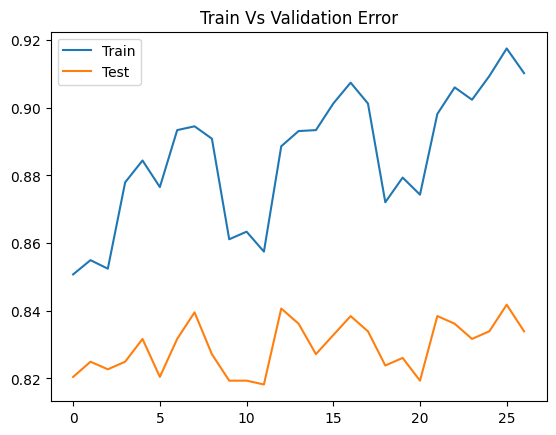

In [134]:
cv_result_df2 = pd.DataFrame(grid_search_xg2.cv_results_)
plt.plot(cv_result_df2["mean_train_score"], label="Train")
plt.plot(cv_result_df2["mean_test_score"], label="Test")
plt.legend()
plt.title("Train Vs Validation Error")
plt.show()

In [135]:
y_scores_stack = stack.predict_proba(X_final)[:,1]

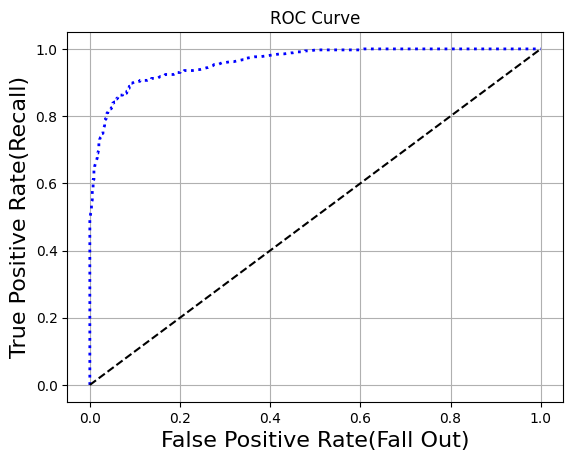

In [138]:
fpr_stck, tpr_stck, _ = roc_curve(y_final, y_scores_stack)

plt.plot(fpr_stck, tpr_stck, "b:", linewidth=2, label="StackClassifier")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate(Fall Out)", fontsize=16)
plt.ylabel("True Positive Rate(Recall)", fontsize=16)
plt.grid(True)
plt.title("ROC Curve")
plt.show()

In [137]:
test_data

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize
0,892,3,0,2.0,7.8292,Q,1,0
1,893,3,1,2.0,7.0000,S,3,1
2,894,2,0,3.0,9.6875,Q,1,0
3,895,3,0,1.0,8.6625,S,1,0
4,896,3,1,1.0,12.2875,S,3,2
...,...,...,...,...,...,...,...,...
413,1305,3,0,NaN,8.0500,S,1,0
414,1306,1,1,2.0,108.9000,C,5,0
415,1307,3,0,2.0,7.2500,S,1,0
416,1308,3,0,NaN,8.0500,S,1,0


In [141]:
def test_data_prediction(X, preprocessor, algo):
    X_test, test_id = X.drop(["PassengerId"], axis=1), X["PassengerId"]
    X_preprocessed = preprocessor.fit_transform(X_test)
    y_pred = algo.predict(X_preprocessed)
    submission = pd.DataFrame({"PassengerId": test_id, "Survived": y_pred})
    return submission

In [145]:
predictions = test_data_prediction(test_data, preprocessor, stack)

In [146]:
submission_df = pd.read_csv("/kaggle/input/competitions/titanic/gender_submission.csv")
submission_df["Survived"] = predictions["Survived"]
submission_df.to_csv("/kaggle/working/submission.csv", index=False)

In [148]:
read_submission = pd.read_csv("/kaggle/working/submission.csv")

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
